In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# 데이터 로드
orders = pd.read_csv('../data/olist_orders_dataset.csv')
items = pd.read_csv('../data/olist_order_items_dataset.csv')
payments = pd.read_csv('../data/olist_order_payments_dataset.csv')

# datetime 변환
timestamp_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in timestamp_cols:
    orders[col] = pd.to_datetime(orders[col])

items['shipping_limit_date'] = pd.to_datetime(items['shipping_limit_date'])

# KPI 계산
orders['payment_approval_time'] = (orders['order_approved_at'] - orders['order_purchase_timestamp']).dt.total_seconds() / 3600
orders['seller_processing_time'] = (orders['order_delivered_carrier_date'] - orders['order_approved_at']).dt.total_seconds() / 3600
orders['carrier_delivery_time'] = (orders['order_delivered_customer_date'] - orders['order_delivered_carrier_date']).dt.total_seconds() / 3600
orders['total_delivery_time'] = (orders['order_delivered_customer_date'] - orders['order_purchase_timestamp']).dt.total_seconds() / 3600
orders['delivery_delay'] = (orders['order_delivered_customer_date'] - orders['order_estimated_delivery_date']).dt.total_seconds() / 3600

# delivered 필터링 + 결측치 제거
orders_delivered = orders[orders['order_status'] == 'delivered']
orders_delivered = orders_delivered.dropna(subset=['order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date'])

C:\Users\준희\AppData\Local\Temp\ipykernel_12156\3880113877.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([


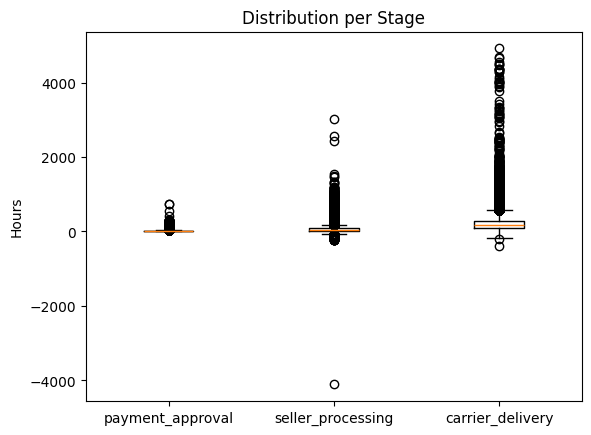

In [2]:
# 박스플롯으로 분포 확인
plt.boxplot([
    orders_delivered['payment_approval_time'],
    orders_delivered['seller_processing_time'],
    orders_delivered['carrier_delivery_time']
], labels=['payment_approval', 'seller_processing', 'carrier_delivery'])

plt.ylabel('Hours')
plt.title('Distribution per Stage')
plt.show()

In [3]:
# 음수 개수 확인
print((orders_delivered['payment_approval_time'] < 0).sum())
print((orders_delivered['seller_processing_time'] < 0).sum())
print((orders_delivered['carrier_delivery_time'] < 0).sum())

0
1350
23


In [4]:
# seller_processing 음수 탐구
anomaly = orders_delivered[orders_delivered['seller_processing_time'] < 0]

# payment_type 분포
negative_seller = anomaly.merge(payments, on='order_id', how='left')
print(negative_seller['payment_type'].value_counts())
print(f"\n전체 대비 비율: {len(anomaly) / len(orders_delivered) * 100:.2f}%")

# seller 분포
negative_seller_items = anomaly.merge(items[['order_id', 'seller_id']], on='order_id', how='left')
print(negative_seller_items['seller_id'].value_counts().head(10))
print(f"\n고유 seller 수: {negative_seller_items['seller_id'].nunique()}")

# 역전 정도 확인
anomaly_gap = (anomaly['order_approved_at'] - anomaly['order_delivered_carrier_date']).dt.total_seconds() / 3600
print(anomaly_gap.describe())

# order_status 확인
print(anomaly['order_status'].value_counts())

payment_type
credit_card    1007
boleto          285
voucher          62
debit_card       44
Name: count, dtype: int64

전체 대비 비율: 1.40%
seller_id
6560211a19b47992c3666cc44a7e94c0    54
955fee9216a65b617aa5c0531780ce60    36
da8622b14eb17ae2831f4ac5b9dab84a    29
ea8482cd71df3c1969d7b9473ff13abc    27
1025f0e2d44d7041d6cf58b6550e0bfa    23
a1043bafd471dff536d0c462352beb48    20
06a2c3af7b3aee5d69171b0e14f0ee87    19
9f505651f4a6abe901a56cdc21508025    17
640e21a7d01df7614a3b4923e990d40c    16
4a3ca9315b744ce9f8e9374361493884    16
Name: count, dtype: int64

고유 seller 수: 583
count    1350.000000
mean       24.702971
std       115.655225
min         0.005833
25%         1.412847
50%        17.159722
75%        25.953333
max      4109.256111
dtype: float64
order_status
delivered    1350
Name: count, dtype: int64


In [5]:
# carrier_delivery 음수 탐구
anomaly_carrier = orders_delivered[orders_delivered['carrier_delivery_time'] < 0]

gap_carrier = (
    anomaly_carrier['order_delivered_carrier_date']
    - anomaly_carrier['order_delivered_customer_date']
).dt.total_seconds() / 3600

print(gap_carrier.nlargest(10))


34939    386.308056
27470    189.095000
45302    171.970278
14474    144.238889
49933    137.663611
71227    136.569722
74967    120.948333
41636    118.639444
6437      69.417222
78556     47.639167
dtype: float64


In [6]:
# 이상치 제거
orders_delivered = orders_delivered[
    (orders_delivered['seller_processing_time'] >= 0) &
    (orders_delivered['carrier_delivery_time'] >= 0)
]
print(orders_delivered.shape)

(95082, 13)


In [9]:
print(orders_delivered['seller_processing_time'].describe(percentiles=[0.25, 0.50, 0.75, 0.95, 0.99]))
print()
print(orders_delivered['carrier_delivery_time'].describe(percentiles=[0.25, 0.50, 0.75, 0.95, 0.99]))

orders_delivered.nlargest(5, 'seller_processing_time')[
    ['order_id', 'order_purchase_timestamp', 'order_approved_at', 
     'order_delivered_carrier_date', 'order_delivered_customer_date', 'seller_processing_time']
]

count    95082.000000
mean        68.441959
std         83.591601
min          0.004167
25%         21.611667
50%         44.371528
75%         86.781111
95%        195.140042
99%        411.338894
max       3018.301667
Name: seller_processing_time, dtype: float64

count    95082.000000
mean       224.738670
std        210.466074
min          0.000000
25%         98.666944
50%        170.647778
75%        289.387708
95%        583.836611
99%        984.617664
max       4924.583333
Name: carrier_delivery_time, dtype: float64


,order_id,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,seller_processing_time
36305,da81fbc27b55e0f3d2813cf2078dc780,2017-11-14 21:07:55,2017-11-14 21:26:34,2018-03-20 15:44:40,2018-03-21 00:18:54,3018.301667
35213,97f48024fcc76f1898e397ad6966e3a0,2017-11-29 12:25:00,2017-11-29 12:41:24,2018-03-16 13:58:02,2018-03-16 13:58:10,2569.277222
3077,8b7fd198ad184563c231653673e75a7f,2017-11-14 10:04:27,2017-11-17 08:47:00,2018-02-26 17:27:15,2018-02-27 18:05:08,2432.670833
44200,866314550f6d7a55c82917d9b4463e1f,2017-11-16 14:55:04,2017-11-18 02:31:11,2018-01-21 16:12:17,2018-01-25 19:38:35,1549.685000
71854,5cc475c7c03290048eb2e742cd64cb5e,2016-10-04 21:54:52,2016-10-05 03:10:31,2016-12-06 17:24:00,2016-12-12 20:31:54,1502.224722


C:\Users\준희\AppData\Local\Temp\ipykernel_12156\1385307988.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([


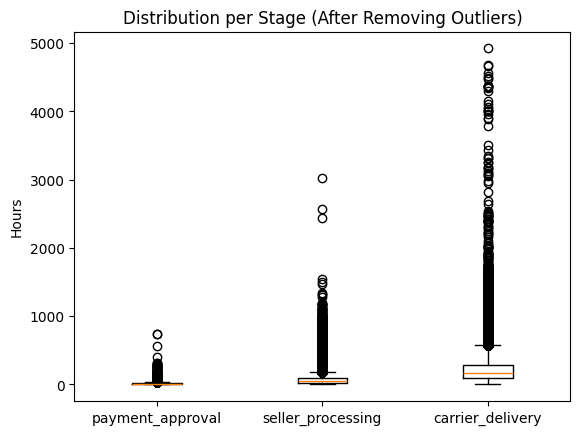

In [11]:
plt.boxplot([
    orders_delivered['payment_approval_time'],
    orders_delivered['seller_processing_time'],
    orders_delivered['carrier_delivery_time']
], labels=['payment_approval', 'seller_processing', 'carrier_delivery'])

plt.ylabel('Hours')
plt.title('Distribution per Stage (After Removing Outliers)')
plt.show()

In [12]:
orders_delivered.to_csv('../data/orders_delivered_clean.csv', index=False)